# 2.4. Imperfect relocations

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from types import SimpleNamespace
import time

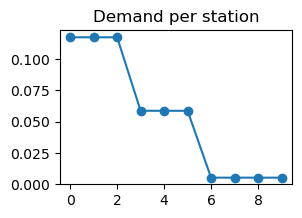

In [38]:
# Repeat the same configs as in the "optimal relo frequency" notebook

def update_config(cfg):
    # To interpret our data financially, renormalize them to typical daily values for real cities
    # cfg.cm1_factor = 20*5/max(cfg.demand) # Assume 20 trips/day from the hottest zone, and 5 €/trip CM1
    cfg.time_factor = 100/sum(cfg.demand)  # Let's insist on 100 rentals a day, to be able to directly compare different demand shapes
    cfg.cm1_factor = 5  # CM1 contribution per trip, Eur
    cfg.cm2_factor = 20  # CM2 cost of a car per day, Eur
    cfg.relo_cost = 20  # Relo cost per trip
    return cfg

def get_config(scenario, **kwargs):
    """Return a config of values as a SimpleNamespace."""
    d = {}
    d['scenario'] = scenario
    d['n_stations'] = 10
    d['n_cars'] = 15
    d['relo_period'] = 50

    d['n_steps_preparation'] = 20000 # For how many steps stats are NOT collected
    d['n_steps_per_experiment'] = 5000
    d['n_experiments'] = 100
    d['start_condition'] = "uniform"

    out = SimpleNamespace(**d)

    # Now set any manual corrections, if any.
    # Warning: as we're doing it here, all properties that are set afterwards are not settable via get_config(key=value) interface.
    # It's not a good design, but also this is just a notebook, not a package.
    for key, value in kwargs.items():
        setattr(out, key, value)

    # Calculate demand
    if scenario == 'linear':
        out.demand = np.arange(out.n_stations, 0, -1)
    elif scenario == 'dropoff':
        out.demand = np.array([1/(1 + i) for i in range(out.n_stations)])  # Drop-off
    elif scenario == 'steps':
        out.demand = np.zeros(out.n_stations)
        n_steps = 3
        n_within = out.n_stations // n_steps
        for i in range(n_steps):
            j = i*n_within
            out.demand[j:min(j+n_within, out.n_stations)] = n_steps - i - 1
    elif scenario == 'cosine':
        out.demand = np.array([np.cos(i/(out.n_stations-1)*np.pi) + 1.2 for i in range(out.n_stations)])  # Hat

    out.demand = out.demand / out.demand.sum()  # First take
    out.demand = np.maximum(out.demand, 0.01)  # Sanitation
    out.demand = out.demand / out.demand.sum() * 0.55  # Final take (the magic number makes the top demand close to 0.1)
    # We need to keep these values low enough, for our binomial process to represent a Poisson process well enough.
    # The actual scaling factor doesn't matter much for CM2 calculations, as we set the CM1 coefficient manually anyways (below)
    # The only two things that matter here are that 1) the shape of the distribution is correct,
    # 2) the values are small enough to resemble Poisson process

    out = update_config(out)
    return out

# Practical test
cfg = get_config('steps', n_stations=10)

plt.figure(figsize=(3, 2)) # Visualize demand, to be sure
plt.plot(cfg.demand, 'o-')
plt.ylim(0, None)
plt.title("Demand per station");

In [ ]:
# Main loop, performing (and counting) profitable relocations

def run_model(cfg, scenario="perfect", seed=None):
    """Main modeling loop as a method"""
    if seed is None:
        seed = int(time.time() * 1000000) % 2**32
    np.random.seed(seed)

    # Make copies of some variables for brevity reasons
    n_steps = cfg.n_steps_preparation + cfg.n_steps_per_experiment*cfg.n_experiments
    n_stations = cfg.n_stations
    demand = cfg.demand  # For shorter formulas only
    tick_length_days = demand.sum() / 200   # To recalculate n events to "daily events"
    print(f"Time in the model (per experiment): {cfg.n_steps_per_experiment*tick_length_days:.1f} days")

    cm1 = np.zeros(shape=(cfg.n_experiments, n_stations))
    average_cars = np.zeros(shape=(cfg.n_experiments, n_stations))
    total_attempts = np.zeros(shape=(cfg.n_experiments, n_stations))
    total_rentals = np.zeros(shape=(cfg.n_experiments, n_stations))
    total_relos = np.zeros(shape=(cfg.n_experiments, n_stations))

    # Distribute cars uniformly
    state = np.array([cfg.n_cars // cfg.n_stations]*n_stations) # Case of cars being distributed uniformly
    state[0] = state[0] + (cfg.n_cars - sum(state))  # Correction in case division failed us

    for i_step in range(n_steps):
        attempts = (np.random.uniform(size=cfg.n_stations) < demand) # If a car was ordered
        departures = attempts * (state > 0)
        destinations = np.random.choice(
            n_stations, size=n_stations, p=demand/sum(demand)) # Where a car would go if ordered
        # The formula above assumes that ultimately in and out flows for every station are balanced, so if
        # few people depart from the station (low demand), it will also be unlikely to become a destination
        # (that's why NORMALIZED demand is used as a probability parameter for random.choice)

        if (i_step >= cfg.n_steps_preparation) & ((i_step - cfg.n_steps_preparation) % cfg.n_steps_per_experiment == 0):
            i_experiment = (i_step - cfg.n_steps_preparation) // cfg.n_steps_per_experiment
            print('.', end='') # Experiment counter

        destinations[~departures] = -1 # If the car didn't leave then it doesn't arrive anywhere
        arrivals = [sum(destinations==i) for i in range(n_stations)] # Manual pivot table

        state = state - departures + arrivals

        # Potential Relocations!
        # Find where to relocate from
        demand_per_car = demand/state.clip(1, None) # Demand in the absence of a relo
        bad_zone_demand = demand_per_car[state>0].min()
        start_relo = np.where((demand_per_car == bad_zone_demand) & (state > 0))[0][0]
        # Find where to relocate to
        demand_per_car = demand/(1 + state) # After relo demand
        good_zone_demand = demand_per_car.max()
        end_relo = np.where(demand_per_car == good_zone_demand)[0][0]
        # Now decide if we want to relocate or not
        relo_impact = (
            cfg.cm2_factor * tick_length_days * (1/bad_zone_demand - 1/good_zone_demand) - cfg.relo_cost
        )
        # print(f"from {start_relo} ({state[start_relo]} cars, {bad_zone_demand:.3f}) "
        #       f"to {end_relo} ({state[end_relo]} cars, {good_zone_demand:.3f}) impact={relo_impact:.3f}")
        if relo_impact > 0: # If profitable, do a relocation

            # --- Scenario-based interruption!
            match scenario:
                case "perfect", "no_relos":
                    pass  # Do nothing
                case "bad_start":
                    # replace start_relo with random zone that has at least one car
                    possible_starts = np.where(state > 0)[0]
                    start_relo = np.random.choice(possible_starts)
                case "bad_end":
                    # replace end_relo with a random zone
                    end_relo = np.random.choice(n_stations)

            if scenario != "no_relos":
                state[start_relo] -= 1
                state[end_relo] += 1
                relo_happened = True
        else:
            relo_happened = False

        if i_step > cfg.n_steps_preparation: # Collect stats
            # CM1 is first shared between target andd destination, then turned from raw numbers to probabilities,
            # then  from probabilities to daily rates using time-factor, then to daily money using money factor
            cm1[i_experiment, :] += (departures + arrivals)/2/cfg.n_steps_per_experiment * cfg.time_factor * cfg.cm1_factor
            average_cars[i_experiment, :] += state/cfg.n_steps_per_experiment  # Average n cars over time
            total_attempts[i_experiment, :] += attempts*1
            total_rentals[i_experiment, :] += departures
            if relo_happened:
                total_relos[i_experiment, start_relo] += 1

    return SimpleNamespace(
            cm1=cm1, average_cars=average_cars, n_apps=total_attempts, n_rentals=total_rentals, n_relos=total_relos
            )

# Test
seed = int(time.time() * 1000000) % 2**32
np.random.seed(seed)

cfg = get_config('steps', n_experiments=1)
out = run_model(cfg)

print("Demand per zone: ", " ".join([f"{x:0.3f}" for x in cfg.demand]))
print("Total relocation starts per zone:", out.n_relos)
print("Rentals per relocation:", out.n_rentals.sum()/out.n_relos.sum())

Time in the model (per experiment): 13.8 days
.Demand per zone:  0.118 0.118 0.118 0.059 0.059 0.059 0.005 0.005 0.005 0.005
Total relocation starts per zone: [[ 0.  0.  0.  0.  0.  0. 16. 12.  5. 10.]]
Rentals per relocation: 48.674418604651166


In [ ]:
# Run the experiments

distribution = "linear"

n_experiments = 30
n_steps_per_experiment = 10000
n_cars = 10

memory_n_relos = np.zeros(shape=(n_experiments, 4))
memory_n_rentals = np.zeros(shape=(n_experiments, 4))
cm2_memory = np.zeros(shape=(n_experiments, 4))

scenarios = ["perfect", "bad_end", "bad_start", "no_relos"]

for i, scenario in enumerate(scenarios):
    print(f"\nScenario: {scenario}")
    cfg = get_config(
        distribution, n_experiments=n_experiments, n_cars=n_cars,
        n_steps_per_experiment=n_steps_per_experiment,
        )
    out = run_model(cfg, scenario, seed=3)

    print("Average n_relos per location: ", out.n_relos.mean(axis=0))

    # Total CM2 per experiment
    relo_expenses = out.n_relos.sum(axis=1) / cfg.n_steps_per_experiment * cfg.relo_cost * cfg.time_factor
    cm2 = out.cm1.sum(axis=1) - cfg.n_cars*cfg.cm2_factor - relo_expenses

    memory_n_relos[:, i] = out.n_relos.sum(axis=1)
    memory_n_rentals[:, i] = out.n_rentals.sum(axis=1)
    cm2_memory[:, i] = cm2
    print(f"Average CM2: {cm2.mean()}")

print("Done")


Scenario: perfect
Time in the model (per experiment): 27.5 days
..............................Average n_relos per location:  [0.         0.         0.         0.         0.         0.
 0.         0.         0.13333333 4.13333333]
Average CM2: 67.65757575757851

Scenario: bad_end
Time in the model (per experiment): 27.5 days
..............................Average n_relos per location:  [0.         0.         0.         0.         0.         0.
 0.         0.         0.06666667 4.53333333]
Average CM2: 66.53939393939665

Scenario: bad_start
Time in the model (per experiment): 27.5 days
..............................Average n_relos per location:  [2.53333333 2.23333333 2.2        2.53333333 1.9        1.33333333
 1.06666667 1.         1.5        3.73333333]
Average CM2: 62.40303030303308

Scenario: no_relos
Time in the model (per experiment): 27.5 days
..............................Average n_relos per location:  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Average CM2: 66.57575757576022
Done


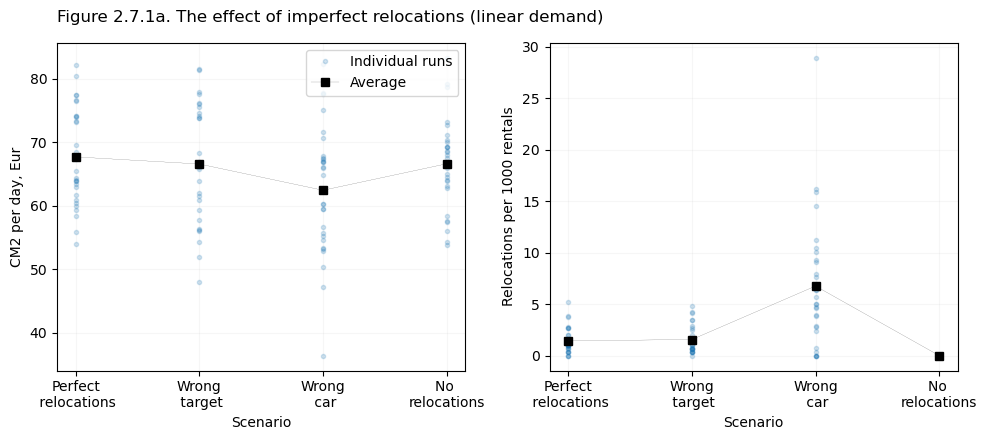

In [43]:
# Visualizer

def make_a_plot(cfg, scenarios, distribution, memory_n_relos, memory_n_rentals, cm2_memory):
    translator = {
        "perfect": "Perfect\n relocations",
        "bad_start": "Wrong\n car",
        "bad_end": "Wrong\n target",
        "no_relos": "No \nrelocations"
    }

    if distribution == "linear":
        letter = "a"
    else:
        letter = ""

    plt.figure(figsize=(10, 4.5))

    plt.subplot(121)
    plt.title(f"Figure 2.7.1{letter}. The effect of imperfect relocations ({distribution} demand)", loc='left', pad=15)

    plt.plot([0,1,2,3]*cfg.n_experiments, cm2_memory.flatten(), '.', color="tab:blue",
            alpha=0.2, label="Individual runs")
    plt.plot([0, 1, 2, 3], cm2_memory.mean(axis=0), 'ks-', label="Average", linewidth=0.1)
    plt.xlabel("Scenario")
    plt.xticks([0, 1, 2, 3], [translator[scenario] for scenario in scenarios])
    plt.ylabel("CM2 per day, Eur");
    plt.grid(alpha=0.1)
    plt.legend(loc="upper right")

    plt.subplot(122)
    plt.plot([0,1,2,3]*cfg.n_experiments, memory_n_relos.flatten()/memory_n_rentals.flatten()*1000,
            '.', color="tab:blue", alpha=0.2, label="Individual runs")
    plt.plot([0, 1, 2, 3], memory_n_relos.mean(axis=0)/memory_n_rentals.mean(axis=0)*1000,
            'ks-', label="Average", linewidth=0.1)
    plt.xlabel("Scenario")
    plt.xticks([0, 1, 2, 3], [translator[scenario] for scenario in scenarios])
    plt.ylabel("Relocations per 1000 rentals");
    plt.grid(alpha=0.1)

    plt.tight_layout()

make_a_plot(cfg, scenarios, distribution, memory_n_relos, memory_n_rentals, cm2_memory)
plt.savefig(f"../figures/02relos_07imperfect_{distribution}.svg", dpi=300)
# without bbox parameter it cuts the title off